## Open-Ended Reflection Questions 

### 1. Training Dynamics

In [1]:
from IPython.display import Image, display
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

#### LSTM Training Curves

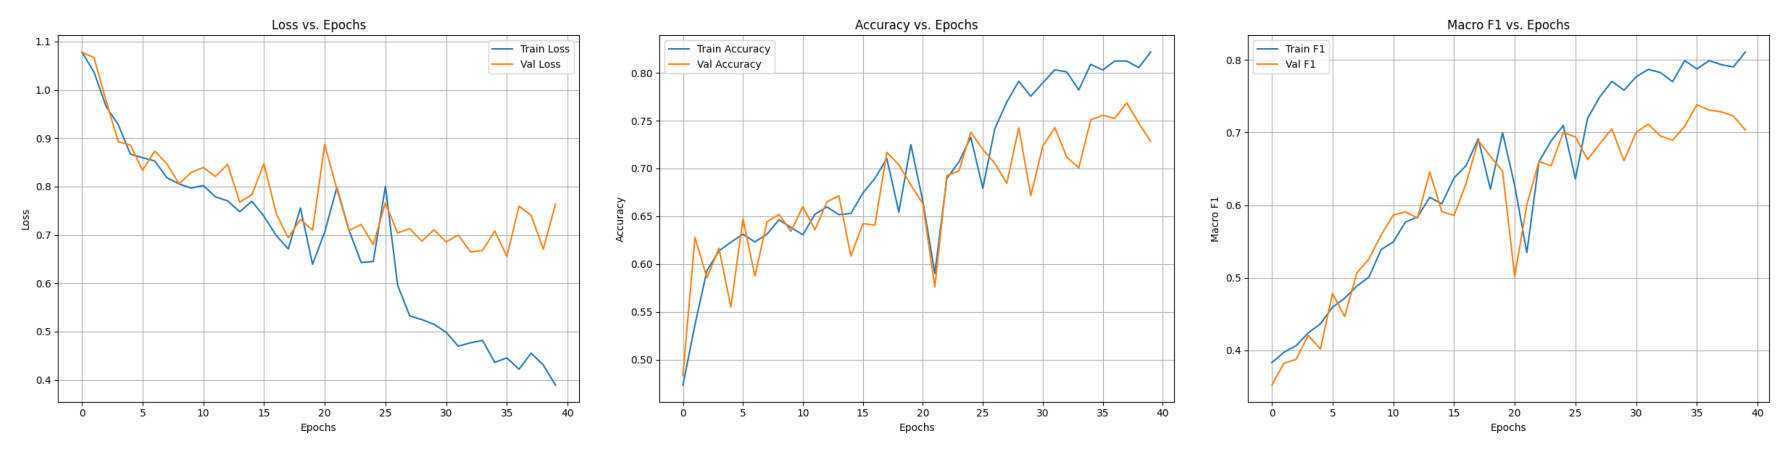

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

images = [
    "outputs/lstm_loss_curve.png",
    "outputs/lstm_accuracy_curve.png",
    "outputs/lstm_f1_curve.png"
]

for ax, img_path in zip(axes, images):
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()

Did your models show signs of overfitting or underfitting?  What architectural or training changes could address this?
In the loss curve, training loss keeps decreasing while validation loss flattens after mid-training. In the accuracy and macro F1 curves, training curves continue to rise, but validation curves level off and fluctuate. The gap between train and validation curves is present but moderate. These patterns suggest that LSTM is mild overfitting but overall good generalization. This behavior could be mitigated through stronger regularization, such as weight decay, or early stopping.

#### MLP Training Curves

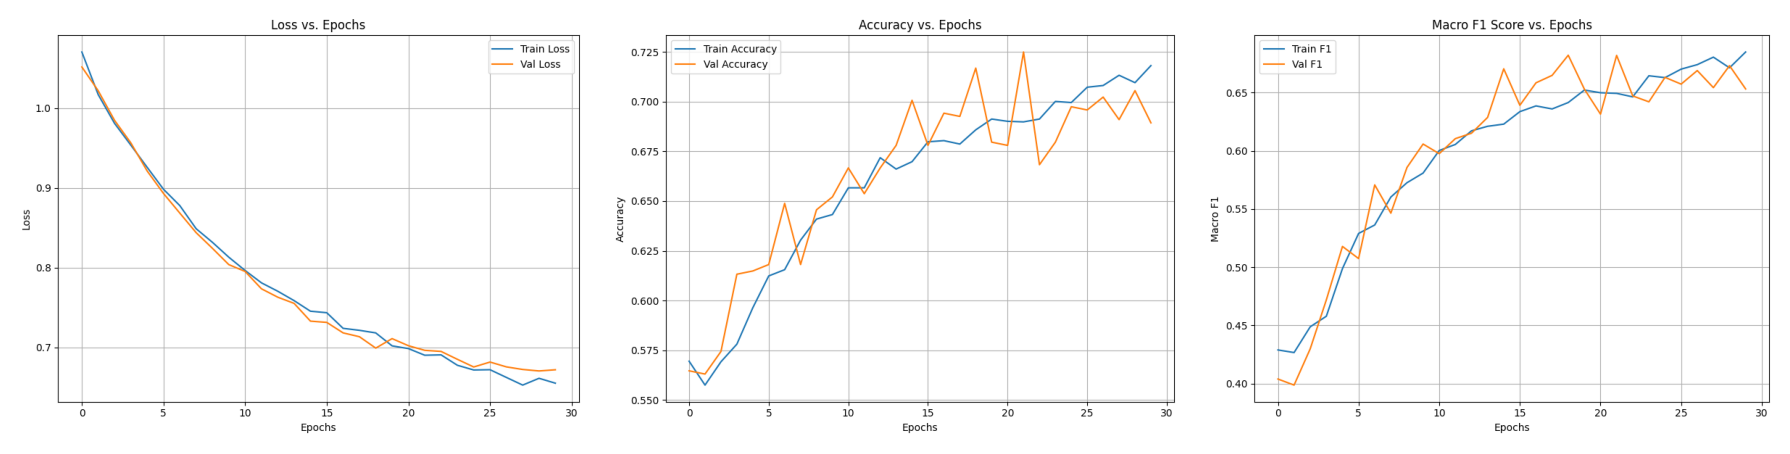

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

images = [
    "outputs/mlp_loss_curve.png",
    "outputs/mlp_accuracy_curve.png",
    "outputs/mlp_f1_curve.png"
]

for ax, img_path in zip(axes, images):
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()

In the loss curve, both training and validation loss decrease slowly and then plateau early. In the accuracy and macro F1 curves, training and validation curves stay close and saturate at relatively low levels and there is no clear widening gap between training and validation curves.This suggest that MLP is underfitting, likely due to insufficient model capacity. This could be addressed by simply training for more epochs.

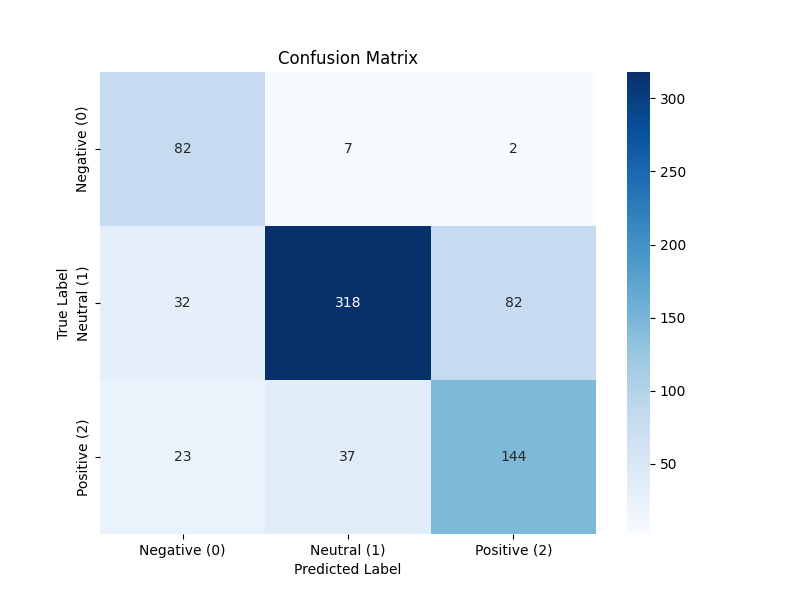

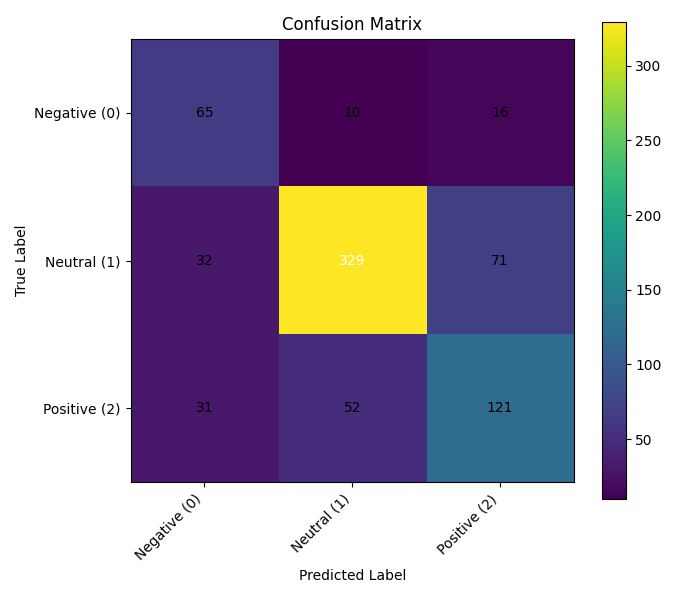

In [6]:
display(Image(filename="outputs/lstm_confusion_matrix.png"))
display(Image(filename="outputs/mlp_confusion_matrix.png"))

How did using class weights affect training stability and final performance?
Based on the evaluation plots and confusion matrix for both models. The class weight effects can be showed as validation loss curves are noisier for both models. Macro F1 improves more consistently than accuracy, especially in later epochs. Furthermore, confusion matrices show fewer extreme failures on minority classes. This is because class weights shift optimization focus toward underrepresented classes and this increases training variance but improves balanced performance.


### Model Performance and Error Analysis

Which of your two models generalized better to the test set?
Based on the Mico F1 scores and confusion matrices. LSTM's Validation Macro F1 curve stabilizes at a higher level, means that ther are smaller gap between validation and test performance. Confusion matrix shows fewer extreme class-wise failures. Move to MLP, the validation Macro F1 saturates earlier and lower, and confusion matrix shows heavier bias toward the Neutral class. Besides, test Macro F1 for LSTM is higher than MLP (0.73 to 0.66). These observations suggest that LSTM generalized better than the MLP.
Which sentiment class was most frequently misclassified?
For both models, the most common errors concentrated positive, negative classes being misclassified as neutral and vice versa. This is likely because the neutral class is more prevalent and less distinctive, leading to more confusion. Thus, Neutral sentiment is the most frequently misclassified class


### Cross-Model Comparison

#### Classical models

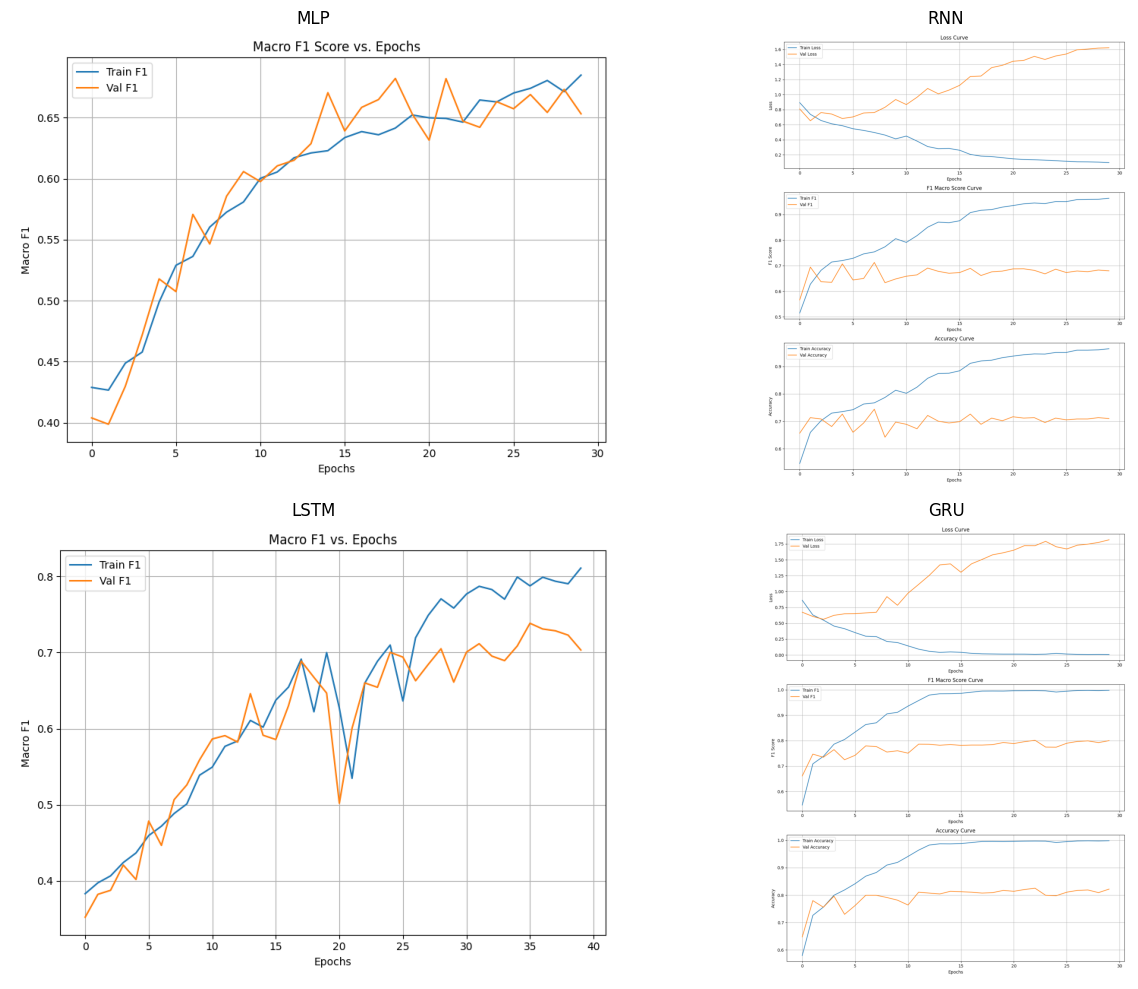

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

images = [
    "outputs/mlp_f1_curve.png",
    "outputs/rnn_f1_learning_curves.png",
    "outputs/lstm_f1_curve.png",
    "outputs/gru_f1_learning_curves.png"
]

titles = ["MLP", "RNN", "LSTM", "GRU"]

for ax, img_path, title in zip(axes.flatten(), images, titles):
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

#### LLMs

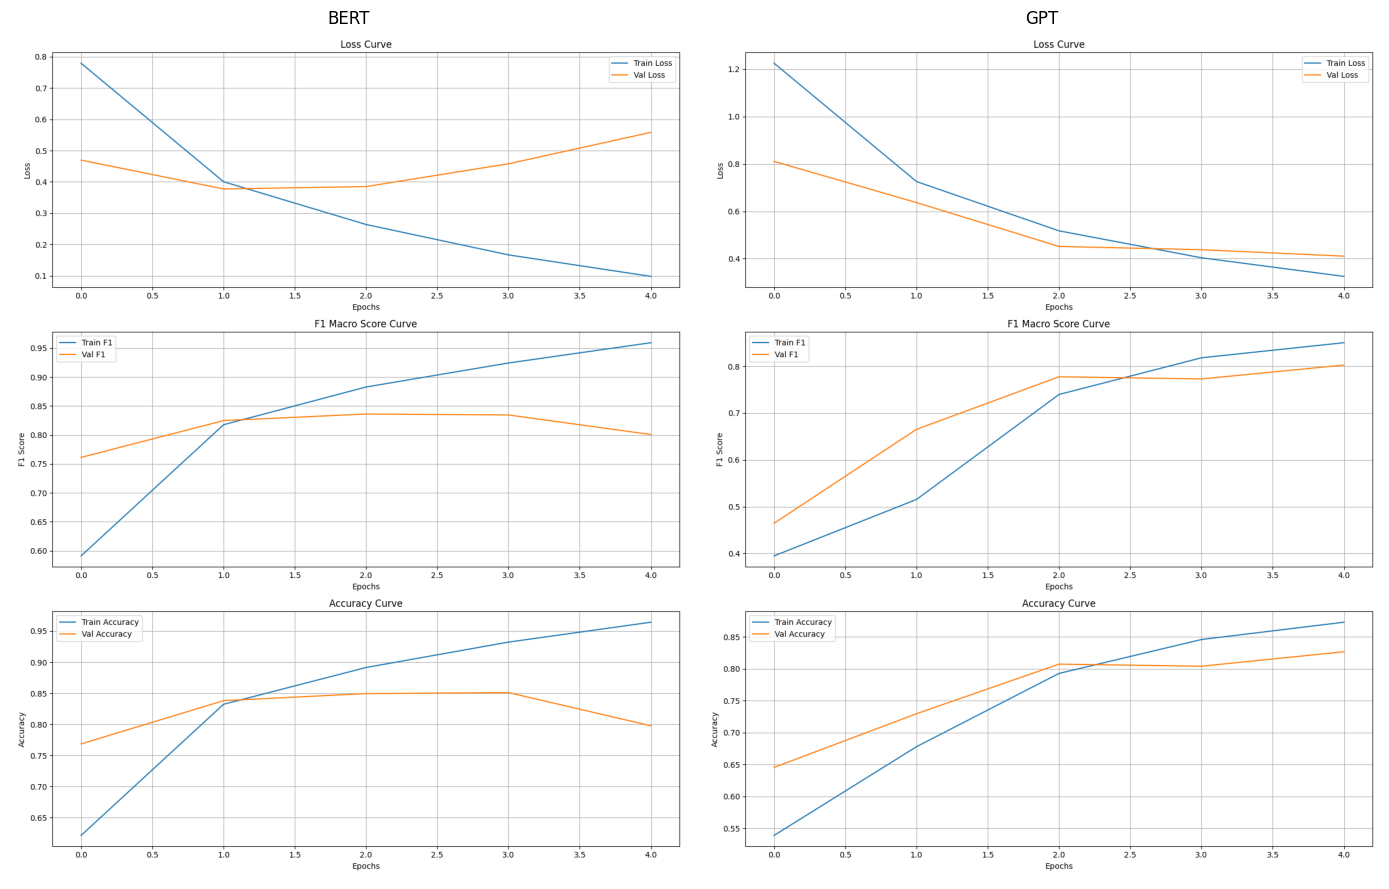

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14,10))

images = [
    "outputs/bert_f1_learning_curves.png",
    "outputs/gpt_f1_learning_curves.png"
]

titles = ["BERT", "GPT"]

for ax, img_path, title in zip(axes, images, titles):
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

a. How did mean-pooled FastText embeddings limit the MLP compared to sequence-based models?
Based on the evaluation plots of MLP. The accuracy and F1 curves plateau early at about 0.65, which is lower than LSTM. Both training and validation curves stay close but at lower levels. Since Mean pooling removes word order and compositional structure, the MLP cannot capture important contextual cues and dependencies that are crucial for sentiment analysis, limit its performance relative to sequence-based models.
b. What advantage did LSTM sequential processing provide over MLP?
As LSTM validation F1 stabilizes at a higher level than MLP, and confusion matrix shows improved handling of Positive/Negative classes. This can by reasoned that LSTM preserves token order and temporal dependencies, which can model phrases like “not good” or sentiment shifts across a sentence. Thus, Sequential modeling allows the LSTM to capture contextual sentiment patterns that the MLP cannot.


c. Did fine-tuned LLMs (BERT/GPT) outperform classical baselines?
Based on the plots, BERT and GPT validation F1 curves are consistently above all classical models, and they show faster convergence with less noisy validation behavior. That's because fine-tuning allows LLMs to adapt their pre-trained representations to the specific sentiment analysis task, leading to better generalization and performance compared to classical models that rely on fixed embeddings or simpler architectures. Thus, fine-tuned LLMs outperformed classical baselines.
d. rank all 6 models: BERT, GPT, LSTM, GRU, RNN, MLP. BERT and GPT rank highest because they use pretrained contextual embeddings, where each token representation depends on its surrounding context. BERT has slower training convergence and Flatter validation curves than gpt, so BERT ranks the first place. LSTM and GRU outperform MLP and RNN because their gated sequential architectures model word order and long-range dependencies, reducing information loss across a sentence. RNN ranks lower because it struggles with long-term dependencies, as evidenced by noisier validation curves and weaker generalization. MLP performs worst because mean-pooled FastText embeddings discard word order and compositional structure, which put sentences with different meaning into similar representations.

## AI Use Disclosure (Required)

If you used any AI-enabled tools (e.g., ChatGPT, GitHub Copilot, Claude, or other LLM assistants) while working on this assignment, you must disclose that use here. The goal is transparency-not punishment.

In your disclosure, briefly include:
- **Tool(s) used:** (name + version if known)
- **How you used them:** (e.g., concept explanation, debugging, drafting code, rewriting text)
- **What you verified yourself:** (e.g., reran the notebook, checked outputs/plots, checked shapes, read documentation)
- **What you did *not* use AI for (if applicable):** (optional)

You are responsible for the correctness of your submission, even if AI suggested code or explanations.

- **Tool(s) used:** ChatGPT 5.2
- **How you used them:** Drafting the tokenize function of LSTM and MLP classifier, check the whole structure of these two classifier to make sure it work, clarify conceptual questions about model behavior, training dynamics, architectural differences.
- **What you verified yourself:** I reran all notebooks and training scripts locally to ensure that the reported metrics and plots matched the outputs shown. I also check confusion matrices, test scores to confirm all the conclusion is reasonable.
